# Foundation models: Using ResNet for skin lesion prediction

Note that this running this notebook requires beefy hardware: Access to a GPU with sufficient
vRAM.

In [1]:
# Install necessary packages (run this if needed)
# !pip install torch torchvision pandas matplotlib seaborn scikit-learn pillow tqdm lightning

# Import libraries
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from PIL import Image
import lightning as L
from lightning.pytorch.loggers import CSVLogger

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## Getting the skin lesion training data

In [3]:
# ! curl -L -o skin-cancer-mnist-ham10000.zip https://www.kaggle.com/api/v1/datasets/download/kmader/skin-cancer-mnist-ham10000
# ! unzip skin-cancer-mnist-ham10000.zip -d data/

In [4]:
metadata = pd.read_csv('data/HAM10000_metadata.csv')
class_counts = metadata['dx'].value_counts()
print("Class distribution:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images ({count/len(metadata)*100:.2f}%)")

Class distribution:
nv: 6705 images (66.95%)
mel: 1113 images (11.11%)
bkl: 1099 images (10.97%)
bcc: 514 images (5.13%)
akiec: 327 images (3.27%)
vasc: 142 images (1.42%)
df: 115 images (1.15%)


## Setting up the data structures

Idem to the practical on convolutional neural nets.

In [5]:
class SkinLesionDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform
        self.classes = sorted(df['dx'].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        img_id = self.df.iloc[idx]['image_id']
        img_path = os.path.join(self.image_dir, 'data/HAM10000_images_part_1', f"{img_id}.jpg")
        if not os.path.exists(img_path):
            img_path = os.path.join(self.image_dir, 'data/HAM10000_images_part_2', f"{img_id}.jpg")
        image = Image.open(img_path).convert('RGB')
        diagnosis = self.df.iloc[idx]['dx']
        label = self.class_to_idx[diagnosis]
        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
class SkinLesionDataModule(L.LightningDataModule):
    def __init__(
        self,
        metadata: pd.DataFrame,
        image_dir: str = '.',
        batch_size: int = 32,
        num_workers: int = 4,
        test_size: float = 0.2,
        random_state: int = 42,
    ):
        super().__init__()
        self.metadata = metadata
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.test_size = test_size
        self.random_state = random_state

        self.train_dataset = None
        self.val_dataset = None
        self.class_names = None

    def setup(self, stage=None):
        train_df, val_df = train_test_split(
            self.metadata,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=self.metadata['dx'],
        )

        self.train_dataset = SkinLesionDataset(
            df=train_df,
            image_dir=self.image_dir,
            transform=DATA_TRANSFORMS['train'],
        )

        self.val_dataset = SkinLesionDataset(
            df=val_df,
            image_dir=self.image_dir,
            transform=DATA_TRANSFORMS['val'],
        )

        self.class_names = self.train_dataset.classes

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
        )

Here we also apply transformations to (1) enrich our training dataset and (2) to make our model
more robust against variances.

In [7]:
# Define data transformations
DATA_TRANSFORMS = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Initialize data module
DATA_MODULE = SkinLesionDataModule(
    metadata=metadata,
    image_dir='.',
    batch_size=32,
    num_workers=4,
)
DATA_MODULE.setup()

print(f"Training set size: {len(DATA_MODULE.train_dataset)}")
print(f"Validation set size: {len(DATA_MODULE.val_dataset)}")
class_names = DATA_MODULE.class_names
print(f"Class names: {class_names}")

Training set size: 8012
Validation set size: 2003
Class names: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## Setup the model architecture

This includes loading the ResNet architecture together with its weights, and updating where
necessary. We can choose to freeze the first layers of the ResNet model to make training more
efficient. We also have to replace the linear prediction layers that were trained on general
image data recognition tasks with our own new layers for skin lesion prediction.

Replacing the linear layers is mostly needed as our prediction task requires one output node per
skin lesion class in the output layer. The original ResNet output layer had a different dimension.

In [8]:
class LitResNetTransferModel(L.LightningModule):
    def __init__(self, freeze_layers=20, num_classes=7, lr=1e-4):
        super().__init__()
        self.save_hyperparameters()

        # Load the ResNet foundation model
        self.model = torchvision.models.resnet50(weights="IMAGENET1K_V1")

        # Freeze the early layers
        for param in list(self.model.parameters())[:-freeze_layers]:
            param.requires_grad = False

        # Replace the final fully connected layer
        num_features = self.model.fc.in_features
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
        self.model.fc = self.classifier

        # Minimal reusable blocks for latent space extraction
        self.feature_extractor = nn.Sequential(*list(self.model.children())[:-1])
        self.criterion = nn.CrossEntropyLoss()
        self.predict_mode = "labels"  # one of: "labels", "embeddings"

    def predict_embedding(self, x) -> torch.Tensor:
        """Return latent space before final classification layer."""
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        return x

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))
        self.log("val_acc", acc, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))

    def predict_step(self, batch, batch_idx):
        x, y = batch
        if self.predict_mode == "embeddings":
            emb = self.predict_embedding(x)
            return emb, y
        elif self.predict_mode == "labels":
            preds = torch.argmax(self(x), dim=1)
            return preds, y
        else:
            raise ValueError("Invalid predict mode")

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.hparams.lr)

## Inspecting the native ResNet latent space (embedding) for skin lesions

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/ralf/D012554A_2025/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://py

Predicting: |          | 0/? [00:00<?, ?it/s]

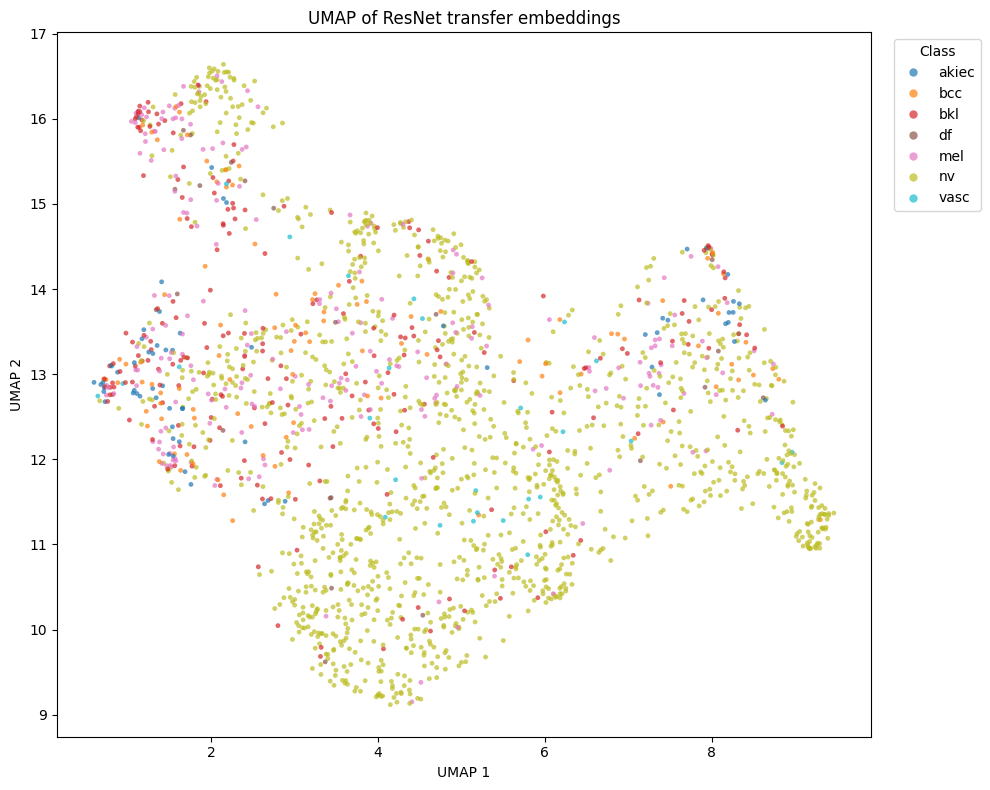

In [9]:
# Get embeddings for UMAP visualization (Lightning model + trainer.predict)
import umap.umap_ as umap

# Setting up the model
lit_transfer_model = LitResNetTransferModel(num_classes=len(class_names), lr=1e-4)
lit_transfer_model.eval()
lit_transfer_model.freeze()
lit_transfer_model.predict_mode = "embeddings"

# Configuring the trainer
trainer = L.Trainer(accelerator="auto")

embedding_outputs = trainer.predict(lit_transfer_model, dataloaders=DATA_MODULE.val_dataloader())
embeddings = torch.cat([emb for emb, _ in embedding_outputs], dim=0).cpu().numpy()
labels = torch.cat([y for _, y in embedding_outputs], dim=0).cpu().numpy()

# Reset model to classification prediction mode
lit_transfer_model.predict_mode = "labels"

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
    n_jobs=1,
)
embeddings_2d = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=labels,
    cmap="tab10",
    alpha=0.7,
    s=12,
    linewidths=0,
    rasterized=True,
)
plt.title("UMAP of ResNet transfer embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

handles, _ = scatter.legend_elements()
plt.legend(handles, class_names, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Question: What do we observe?

## Evaluate foundation model that is not yet pretrained

As a baseline, we'll try to get predictions from the model without any finetuning. Note that
we do NOT expect this to work well, as the final layers have been replaced with randomly initialized
model weights. They have never seen an image and do not know what predictions we expect for the skin
lesions. The final predictions will therefore be random.

In [10]:
# Setting up the model
lit_transfer_model = LitResNetTransferModel(num_classes=len(class_names), lr=1e-4)
logger = CSVLogger(save_dir=".", name="lightning_logs", version="resnet_transfer")

# Configuring the trainer
trainer = L.Trainer(
    max_epochs=10,
    accelerator="auto",
    logger=logger,
    log_every_n_steps=1,
)

# Getting
raw_preds = trainer.predict(lit_transfer_model, dataloaders=DATA_MODULE.val_dataloader())
y_pred_tl = torch.cat([p for p, _ in raw_preds]).cpu().numpy()
y_true_tl = torch.cat([y for _, y in raw_preds]).cpu().numpy()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/ralf/D012554A_2025/.venv/lib/python3.13/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory ./lightning_logs/resnet_transfer exists and is not empty. Previous log files 

Predicting: |          | 0/? [00:00<?, ?it/s]

Classification Report (Transfer Learning):
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        65
         bcc       0.06      0.69      0.12       103
         bkl       0.00      0.00      0.00       220
          df       0.00      0.00      0.00        23
         mel       0.18      0.01      0.02       223
          nv       0.69      0.44      0.54      1341
        vasc       0.00      0.00      0.00        28

    accuracy                           0.33      2003
   macro avg       0.13      0.16      0.10      2003
weighted avg       0.48      0.33      0.37      2003



/home/ralf/D012554A_2025/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ralf/D012554A_2025/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ralf/D012554A_2025/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

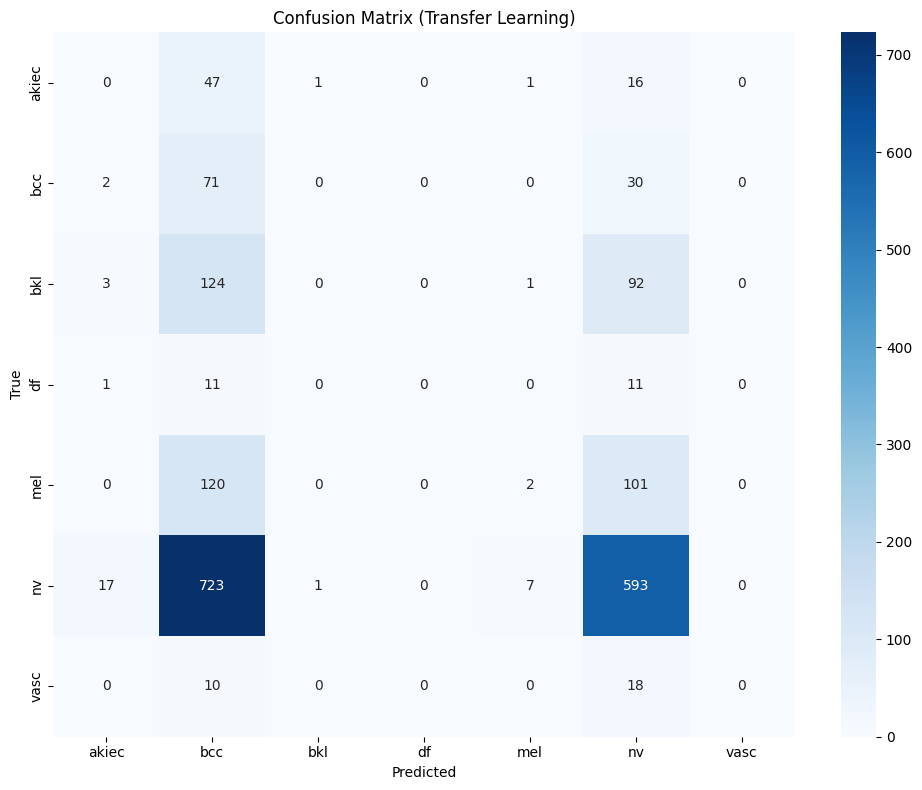

In [11]:
# Classification report
print("Classification Report (Transfer Learning):")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Transfer Learning)")
plt.tight_layout()
plt.show()

As expected, the untrained model is getting a very low accuracy. Even though the first layers have been trained on a foundation model,
the new linear layers in the classification head are untrained. So while the convolutional blocks can make some sense of the images (see the latent space above), the final layers cannot classify the skin lesions.

## Finetuning the model and evaluate

In [12]:
# Train
num_epochs_transfer = 10

lit_transfer_model = LitResNetTransferModel(num_classes=len(class_names), lr=1e-4)
logger = CSVLogger(save_dir=".", name="lightning_logs", version="resnet_transfer")

trainer = L.Trainer(
    max_epochs=num_epochs_transfer,
    accelerator="auto",
    logger=logger,
    log_every_n_steps=1,
)
trainer.fit(lit_transfer_model, datamodule=DATA_MODULE)

torch.save(lit_transfer_model.model.state_dict(), "skin_lesion_transfer_learning.pth")

# Evaluate
raw_preds = trainer.predict(lit_transfer_model, dataloaders=DATA_MODULE.val_dataloader())
y_pred_tl = torch.cat([p for p, _ in raw_preds]).cpu().numpy()
y_true_tl = torch.cat([y for _, y in raw_preds]).cpu().numpy()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/ralf/D012554A_2025/.venv/lib/python3.13/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory ./lightning_logs/resnet_transfer exists and is not empty. Previous log files 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/ralf/D012554A_2025/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/ralf/D012554A_2025/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

Classification Report (Transfer Learning):
              precision    recall  f1-score   support

       akiec       0.80      0.49      0.61        65
         bcc       0.70      0.71      0.70       103
         bkl       0.69      0.59      0.64       220
          df       0.59      0.57      0.58        23
         mel       0.65      0.53      0.58       223
          nv       0.89      0.95      0.92      1341
        vasc       0.91      0.75      0.82        28

    accuracy                           0.83      2003
   macro avg       0.75      0.66      0.69      2003
weighted avg       0.82      0.83      0.82      2003



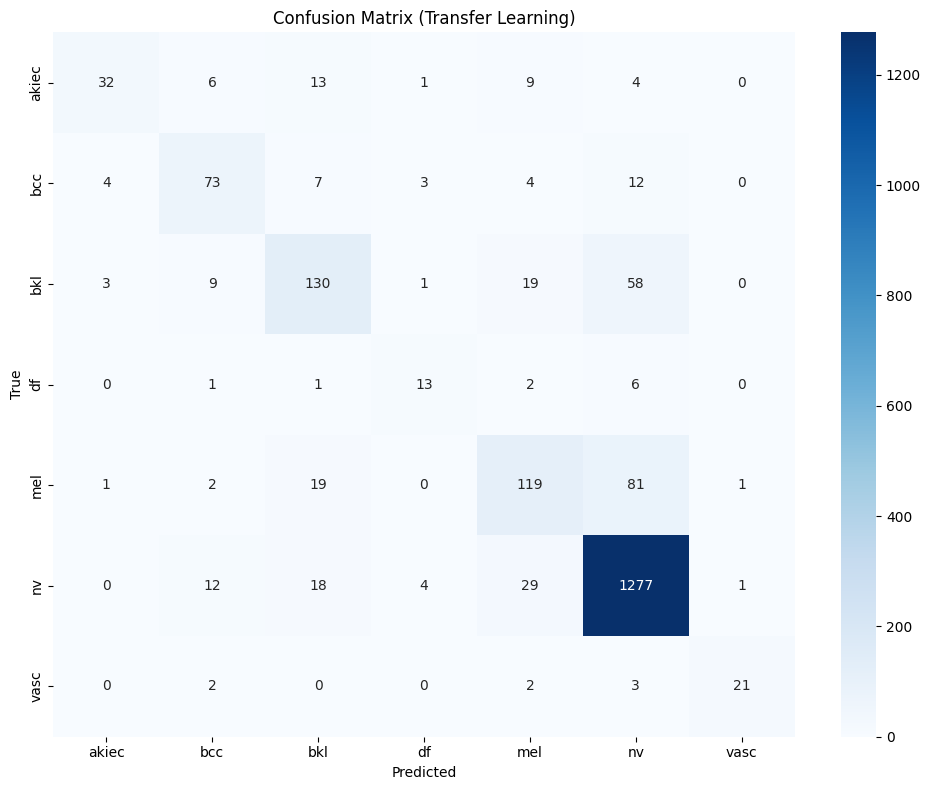

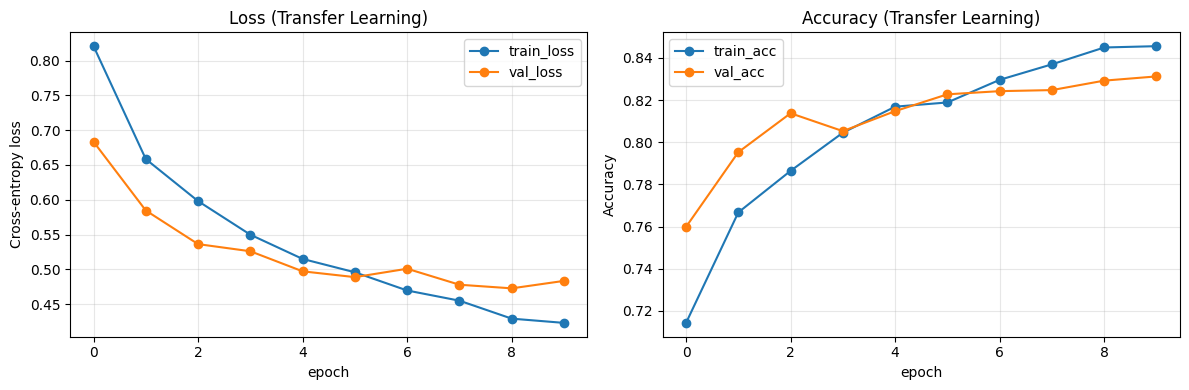

In [13]:
# Classification report
print("Classification Report (Transfer Learning):")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Transfer Learning)")
plt.tight_layout()
plt.show()

# Learning curves from CSVLogger
metrics_path = Path(trainer.logger.log_dir) / "metrics.csv"
metrics = pd.read_csv(metrics_path)

learning_curves = (
    metrics.groupby("epoch", as_index=False)[["train_loss", "val_loss", "train_acc", "val_acc"]]
    .last()
    .sort_values("epoch")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

learning_curves.plot(x="epoch", y=["train_loss", "val_loss"], ax=axes[0], marker="o")
axes[0].set_title("Loss (Transfer Learning)")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].grid(alpha=0.3)

learning_curves.plot(x="epoch", y=["train_acc", "val_acc"], ax=axes[1], marker="o")
axes[1].set_title("Accuracy (Transfer Learning)")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Inspecting the finetuned ResNet latent space (embedding) for skin lesions

Now that the model has been finetuned on skin lesion images, we can also investigate wether the
images of the skin lesion classes better cluster together in the model latent space.

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/ralf/D012554A_2025/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isins

Predicting: |          | 0/? [00:00<?, ?it/s]

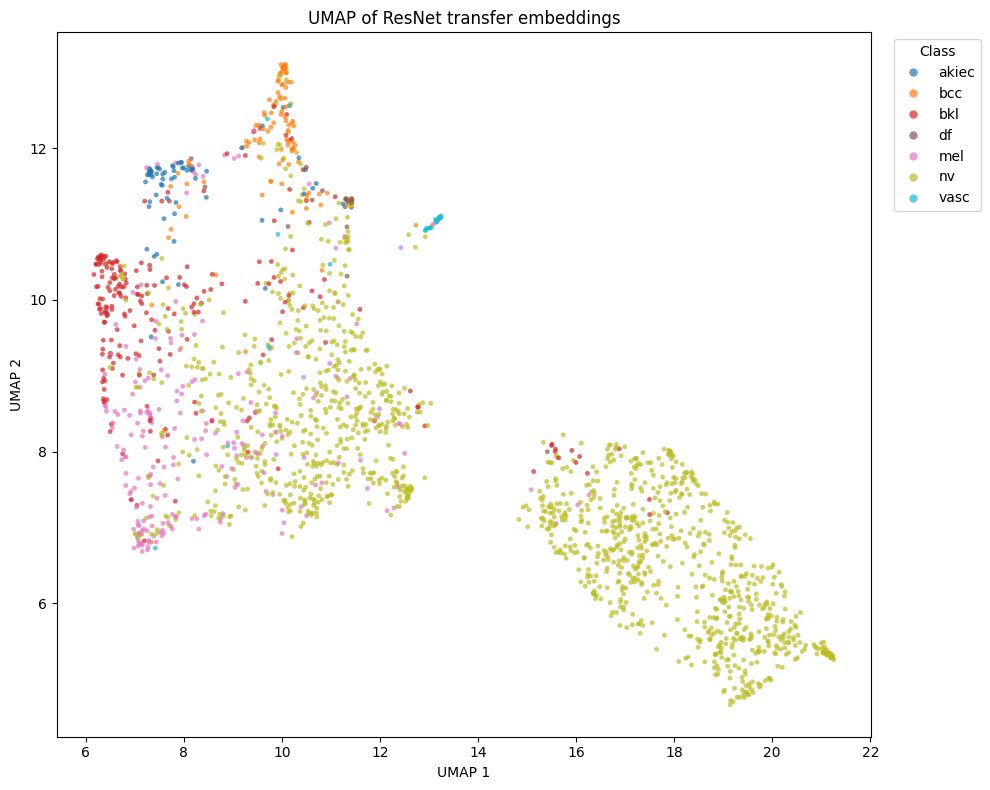

In [14]:
# Get embeddings for UMAP visualization (Lightning model + trainer.predict)
import umap.umap_ as umap

# Setting up the model
# Load from checkpoint
lit_transfer_model = LitResNetTransferModel(num_classes=len(class_names))
lit_transfer_model.model.load_state_dict(torch.load("skin_lesion_transfer_learning.pth"))

# Set to evaluation mode for inference
lit_transfer_model.eval()
lit_transfer_model.freeze()
lit_transfer_model.predict_mode = "embeddings"

# Configuring the trainer
trainer = L.Trainer(accelerator="auto")

embedding_outputs = trainer.predict(lit_transfer_model, dataloaders=DATA_MODULE.val_dataloader())
embeddings = torch.cat([emb for emb, _ in embedding_outputs], dim=0).cpu().numpy()
labels = torch.cat([y for _, y in embedding_outputs], dim=0).cpu().numpy()

# Reset model to classification prediction mode
lit_transfer_model.predict_mode = "labels"

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
    n_jobs=1,
)
embeddings_2d = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=labels,
    cmap="tab10",
    alpha=0.7,
    s=12,
    linewidths=0,
    rasterized=True,
)
plt.title("UMAP of ResNet transfer embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

handles, _ = scatter.legend_elements()
plt.legend(handles, class_names, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The model embedding now clusters the different classes much better, even if not yet perfect.